<a href="https://colab.research.google.com/github/paulinaeb/IDaSec-project/blob/exp3/my_exp3/after_evasion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# model for evasion spam detection using LSTM

This notebook explores the performance of baseline models for spam detection using the **Enron1** dataset and its evasion variants **(charswap, homoglyph, spacing)**. The goal is to evaluate the robustness of machine learning models against adversarial evasion techniques.


The main steps:

1) load LSTM pretrained model on enron1 dataset (before evasion dataset)

2) finetune the model by training it on the new dataset for 6 epochs

3) understand how lstm works in different evasion methods by plotting the same evaluation metrics used before

In [ ]:
!git clone --branch exp4 https://github.com/paulinaeb/IDaSec-project.git

Cloning into 'IDaSec-project'...
remote: Enumerating objects: 430, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (208/208), done.
remote: Total 430 (delta 136), reused 162 (delta 48), pack-reused 166 (from 1)
Receiving objects: 100% (430/430), 41.58 MiB | 18.70 MiB/s, done.
Resolving deltas: 100% (196/196), done.


In [ ]:
!pip uninstall -y torch torchtext

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124


In [ ]:
# !pip install --upgrade torchtext
# !pip install --upgrade torch
!pip install torch==2.2.0 torchtext==0.17.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import warnings as wrn

wrn.filterwarnings('ignore')

import os
import numpy
import pandas as pd
import torch
import torch
from torch.utils.data import DataLoader, Dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package


## Dataloading

**Dataset Loading**

Loaded the original Enron1 dataset (train, val, test) and its evasion variants (charswap, homoglyph, spacing) from their respective subfolders, where:

* charswap: Emails with character-swapping modifications.
*homoglyph: Emails with homoglyph substitutions (e.g., replacing "o" with "0").
*spacing: Emails with added or removed spaces.
* adversarial: Mixed leetspeak with dilution evasion techniques


In [ ]:
# Path to the dataset folder
dataset_path = "IDaSec-project/dataset/enron1"

# List all subfolders in dataset
subfolders = [f.name for f in os.scandir(dataset_path) if f.is_dir()]
print("available datasets:", subfolders)

enron1_charswap_path = dataset_path + "/charswap"
enron1_homoglyph_path = dataset_path + "/homoglyph"
enron1_spacing_path = dataset_path + "/spacing"

enron1_charswap_files = os.listdir(enron1_charswap_path)
print(f"\nFiles in '{enron1_charswap_path}': {enron1_charswap_files}")

enron1_homoglyph_files = os.listdir(enron1_homoglyph_path)
print(f"\nFiles in '{enron1_homoglyph_path}': {enron1_homoglyph_files}")

enron1_spacing_files = os.listdir(enron1_spacing_path)
print(f"\nFiles in '{enron1_spacing_path}': {enron1_spacing_files}")

available datasets: ['mixed', 'charswap', 'spacing', 'homoglyph']

Files in 'IDaSec-project/dataset/enron1/charswap': ['enron1_test_with_charswap.csv', 'enron1_train_with_charswap.csv', 'enron1_val_with_charswap.csv']

Files in 'IDaSec-project/dataset/enron1/homoglyph': ['enron1_train_homoglyph.csv', 'enron1_test_homoglyph.csv', 'enron1_val_homoglyph.csv']

Files in 'IDaSec-project/dataset/enron1/spacing': ['enron1_test_spacing.csv', 'enron1_train_spacing.csv', 'enron1_val_spacing.csv']



### Enron1-charswap

In [ ]:
enron1_charswap_train = pd.read_csv(enron1_charswap_path + "/enron1_test_with_charswap.csv")
enron1_charswap_test = pd.read_csv(enron1_charswap_path + "/enron1_train_with_charswap.csv")
enron1_charswap_val = pd.read_csv(enron1_charswap_path + "/enron1_val_with_charswap.csv")

In [ ]:
enron1_charswap_train.head()

,email,target,email_charswapped,was_augmented
0,Subject: unify / sitara enhancements i am comp...,ham,Subject: unify / sitara enhancements i am comp...,False
1,Subject: weekend activity dated : june 2 thru ...,ham,Subject: weekend activity dated : june 2 thru ...,False
2,Subject: re : tittletattle secrets dn ' t ie n...,spam,"[""Subject: re: tittletattle secrets dn ' t ie ...",True
3,"Subject: deal id 109475 daren , the above deal...",ham,"Subject: deal id 109475 daren , the above deal...",False
4,Subject: weekend entertainment alpha male plus...,spam,['Subject: wekened etneratinmnet aplha amle pl...,True


### Enron1-homoglyph


In [ ]:
enron1_homoglyph_train = pd.read_csv(enron1_homoglyph_path + "/enron1_train_homoglyph.csv")
enron1_homoglyph_test = pd.read_csv(enron1_homoglyph_path + "/enron1_test_homoglyph.csv")
enron1_homoglyph_val = pd.read_csv(enron1_homoglyph_path + "/enron1_val_homoglyph.csv")

In [ ]:
enron1_homoglyph_train.head()

,email,target,email_homoglyph
0,"Subject: prom dress shopping hi , just wanted ...",ham,"Subject: prom dress shopping hi , just wanted ..."
1,"Subject: hi agaain hello , welcome to pharm la...",spam,"𝕾𝓾bjec𝕥∶ hi aga𝕒in hell𝙤 , welcome to p𝒉𝔞ꭈm la..."
2,Subject: feedback monitor error - meter 984132...,ham,Subject: feedback monitor error - meter 984132...
3,Subject: instructions to remove spyware / adwa...,spam,𝘚ubｊ𝕖ctː instructions to r𝖾move sｐℽware / adwa...
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,spam,Sꭒb𝒋𝙚c𝙩︰ a𝕔roba𝘵 𝗉r𝝄 7 𝅭 0 $ 69 . 95 x𝝔 pro op...


### Enron1-spacing


In [ ]:
enron1_spacing_train = pd.read_csv(enron1_spacing_path + "/enron1_train_spacing.csv")
enron1_spacing_test = pd.read_csv(enron1_spacing_path + "/enron1_test_spacing.csv")
enron1_spacing_val = pd.read_csv(enron1_spacing_path + "/enron1_val_spacing.csv")

In [ ]:
enron1_spacing_train.head()

,email,target,email_spaced
0,"Subject: prom dress shopping hi , just wanted ...",ham,"Subject: prom dress shopping hi , just wanted ..."
1,"Subject: hi agaain hello , welcome to pharm la...",spam,"Subject: hi agaain he llo , w e l c o m e to p..."
2,Subject: feedback monitor error - meter 984132...,ham,Subject: feedback monitor error - meter 984132...
3,Subject: instructions to remove spyware / adwa...,spam,Subject: i n s t r u c t i o n s to r e m o v ...
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,spam,Subject: a c r o b a t p r o 7 . 0 $ 69 . 95 x...


In [ ]:
# enron1_spacing_train.info()

### adversarial

In [ ]:
enron1_light_adversarial_train_path = "IDaSec-project/dataset/enron1/enron1_train_lightadversarial.csv"
enron1_light_adversarial_val_path = "IDaSec-project/dataset/enron1/enron1_val_lightadversarial.csv"
enron1_light_adversarial_test_path = "IDaSec-project/dataset/enron1/enron1_test_lightadversarial.csv"

enron1_light_adversarial_train = pd.read_csv(enron1_light_adversarial_train_path)
enron1_light_adversarial_val = pd.read_csv(enron1_light_adversarial_val_path)
enron1_light_adversarial_test = pd.read_csv(enron1_light_adversarial_test_path)

In [ ]:
enron1_light_adversarial_train.head()

,original,adversarial_light,target
0,"Subject: prom dress shopping hi , just wanted ...","Subject: prom dress shopping hi , just wanted ...",ham
1,"Subject: hi agaain hello , welcome to pharm la...","Subject: hi agaain hello , welcome to pharm la...",spam
2,Subject: feedback monitor error - meter 984132...,Subject: feedback monitor error - meter 984132...,ham
3,Subject: instructions to remove spyware / adwa...,Subject: instructions to remove $pyw@r3 / adwa...,spam
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,Subject: acrobat pr0 7 . 0 $ 69 . 95 xp pro op...,spam


In [ ]:
enron1_light_adversarial_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3196 entries, 0 to 3195
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   original           3196 non-null   object
 1   adversarial_light  3196 non-null   object
 2   target             3196 non-null   object
dtypes: object(3)
memory usage: 75.0+ KB


## Evasion Enron1 dataset preparing




**Goal**:

Standardize evasion datasets (charswap, homoglyph, spacing) to a consistent and similar format to the main dataset (before evasion)



### 1. arrange the dataset to have only 2 columns

In [ ]:
# enron1_charswap_train.head()

In [ ]:
# enron1_charswap_test.head()

In [ ]:
# enron1_charswap_val.head()

In [ ]:
def arrange_dataset(dataset):
  # 1) delete email column
  del dataset['email']

  # 2) delete was_augmented column
  del dataset['was_augmented']

  # 3) rename the email_charswapped column to email
  dataset = dataset.rename(columns={'email_charswapped': 'email'})

  # 4) reorder the table where email is at the beginning and target next
  cols = ['email', 'target']
  dataset = dataset[cols]
  return dataset

enron1_charswap_train = arrange_dataset(enron1_charswap_train)
enron1_charswap_test = arrange_dataset(enron1_charswap_test)
enron1_charswap_val = arrange_dataset(enron1_charswap_val)

# arrange homoglyph
def arrange_homoglyph_dataset(dataset):
  # 1) delete email column
  del dataset['email']

  # 2) delete was_augmented column
  dataset = dataset.rename(columns={'email_homoglyph': 'email'})

  cols = ['email', 'target']
  dataset = dataset[cols]
  return dataset

# use rearrange homoglyph dataset function
enron1_homoglyph_train = arrange_homoglyph_dataset(enron1_homoglyph_train)
enron1_homoglyph_test = arrange_homoglyph_dataset(enron1_homoglyph_test)
enron1_homoglyph_val = arrange_homoglyph_dataset(enron1_homoglyph_val)

# arrange spacing
def arrange_spacing_dataset(dataset):
  # 1) delete email column
  del dataset['email']

  # 2) delete was_augmented column
  dataset = dataset.rename(columns={'email_spaced': 'email'})
  cols = ['email', 'target']
  dataset = dataset[cols]
  return dataset

# use arrange spacing function
enron1_spacing_train = arrange_spacing_dataset(enron1_spacing_train)
enron1_spacing_test = arrange_spacing_dataset(enron1_spacing_test)
enron1_spacing_val = arrange_spacing_dataset(enron1_spacing_val)

In [ ]:
enron1_spacing_train.head()

,email,target
0,"Subject: prom dress shopping hi , just wanted ...",ham
1,"Subject: hi agaain he llo , w e l c o m e to p...",spam
2,Subject: feedback monitor error - meter 984132...,ham
3,Subject: i n s t r u c t i o n s to r e m o v ...,spam
4,Subject: a c r o b a t p r o 7 . 0 $ 69 . 95 x...,spam


In [ ]:
enron1_charswap_test.head()


,email,target
0,"Subject: prom dress shopping hi , just wanted ...",ham
1,"['Subject: hi agaani ehllo, welcome to pharm l...",spam
2,Subject: feedback monitor error - meter 984132...,ham
3,"[""Subject: instructions to remove spyware / ad...",spam
4,['Subject: carboat pro 7. 0 $ 69. 95 xp pro op...,spam


In [ ]:
enron1_charswap_val.head()

,email,target
0,Subject: union carbide - seadrift hpl meter # ...,ham
1,"[""Subject: best choice rx - free online rpecsr...",spam
2,Subject: new nat gas delivery location pursuan...,ham
3,Subject: weekend activity dated : june 2 thru ...,ham
4,Subject: meter 5593 daren - canyou get a deal ...,ham


### 2. add the label column

In [ ]:
label_map = {"ham": 0, "spam": 1}

# define a function to add the label column to dataset
def add_label_column(dataset, label_map):
  dataset['label'] = dataset['target'].map(label_map)
  return dataset

############################ Enron1 Charswap ######################################
enron1_charswap_train = add_label_column(enron1_charswap_train, label_map)
enron1_charswap_test = add_label_column(enron1_charswap_test, label_map)
enron1_charswap_val = add_label_column(enron1_charswap_val, label_map)

############################ Enron1 homoglyph ######################################
enron1_homoglyph_train = add_label_column(enron1_homoglyph_train, label_map)
enron1_homoglyph_test = add_label_column(enron1_homoglyph_test, label_map)
enron1_homoglyph_val = add_label_column(enron1_homoglyph_val, label_map)

############################ Enron1 spacing ######################################
enron1_spacing_train = add_label_column(enron1_spacing_train, label_map)
enron1_spacing_test = add_label_column(enron1_spacing_test, label_map)
enron1_spacing_val = add_label_column(enron1_spacing_val, label_map)


### 3. setup tokenizer and vocabulary

**Tokenizer**:
SpaCy’s en_core_web_sm (same as clean data).

**Why**❓

Ensures consistency in tokenization between clean and adversarial examples.

**Per-Dataset Vocabularies:**

Built separately for charswap, homoglyph, and spacing training sets.

**Why**❓

Adversarial perturbations (e.g., "Fréé" vs "Free") introduce new "words"; a shared vocab would treat them as <unk>.



In [ ]:
# use tokenizer from SpaCy
# Special tokens:
# <unk> (out-of-vocab), <pad> (batch padding).
tokenizer = get_tokenizer("spacy", language="en_core_web_sm")

# define the function only in the email column
def yield_tokens(data_iter):
  for index, row in data_iter.iterrows():
        yield tokenizer(row['email'])

# enron1_charswap_vocab
enron1_charswap_vocab = build_vocab_from_iterator(yield_tokens(enron1_charswap_train), specials=["<unk>", "<pad>"])
enron1_charswap_vocab.set_default_index(enron1_charswap_vocab["<unk>"])

# enron1_homoglyph_vocab
enron1_homoglyph_vocab = build_vocab_from_iterator(yield_tokens(enron1_homoglyph_train), specials=["<unk>", "<pad>"])
enron1_homoglyph_vocab.set_default_index(enron1_homoglyph_vocab["<unk>"])

# enron1_spacing_vocab
enron1_spacing_vocab = build_vocab_from_iterator(yield_tokens(enron1_spacing_train), specials=["<unk>", "<pad>"])
enron1_spacing_vocab.set_default_index(enron1_spacing_vocab["<unk>"])


### 4. Create datasets and dataloaders

In [ ]:
class TextDataset(Dataset):
    def __init__(self, data, vocab, tokenizer, label_map):
        self.data = data
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.label_map = label_map

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]  # <-- change this line
        text = torch.tensor(self.vocab(self.tokenizer(item['email'])), dtype=torch.long)
        label = torch.tensor(self.label_map[item['target']], dtype=torch.float)
        return text, label


In [ ]:
def collate_batch(batch,vocab):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=vocab["<pad>"])
    labels = torch.stack(labels)
    return padded_texts, lengths, labels


In [ ]:
BATCH_SIZE = 64
label_map = {"ham": 0, "spam": 1}

# define a function to generate data loader
def generate_data_loader(train_dataset,val_dataset,test_dataset, vocab, tokenizer = tokenizer, label_map = label_map, batch_size = BATCH_SIZE):
  # generate textdataset objects
  train_text_dataset = TextDataset(train_dataset, vocab, tokenizer, label_map)
  val_text_dataset = TextDataset(val_dataset, vocab, tokenizer, label_map)
  test_text_dataset = TextDataset(test_dataset, vocab, tokenizer, label_map)
  # generate dataloader objects
  train_dataloader = DataLoader(train_text_dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda batch: collate_batch(batch, vocab))
  val_dataloader = DataLoader(val_text_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda batch: collate_batch(batch, vocab))
  test_dataloader = DataLoader(test_text_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda batch: collate_batch(batch, vocab))
  return train_dataloader, val_dataloader, test_dataloader

# use generate_data_loader function
train_loader_enron1_charswap, val_loader_enron1_charswap, test_loader_enron1_charswap = generate_data_loader(enron1_charswap_train,enron1_charswap_val,enron1_charswap_test, enron1_charswap_vocab)
train_loader_enron1_homoglyph, val_loader_enron1_homoglyph, test_loader_enron1_homoglyph = generate_data_loader(enron1_homoglyph_train,enron1_homoglyph_val,enron1_homoglyph_test, enron1_homoglyph_vocab)
train_loader_enron1_spacing, val_loader_enron1_spacing, test_loader_enron1_spacing = generate_data_loader(enron1_spacing_train,enron1_spacing_val,enron1_spacing_test, enron1_spacing_vocab)


## Calling pretrained model

In [ ]:
import torch.nn as nn

class LSTMNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super(LSTMNet, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout,
                            batch_first=True)

        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_output, (hidden_state, cell_state) = self.lstm(packed_embedded)

        hidden = torch.cat((hidden_state[-2, :, :], hidden_state[-1, :, :]), dim=1)

        logits = self.fc(hidden)

        return logits  # raw logits (no sigmoid)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EMBEDDING_DIM = 100
NUM_HIDDEN_NODES = 64
NUM_OUTPUT_NODES = 1
NUM_LAYERS = 2
BIDIRECTION = True
DROPOUT = 0.2

SIZE_OF_charswap_VOCAB = len(enron1_charswap_vocab)
SIZE_OF_homoglyph_VOCAB = len(enron1_homoglyph_vocab)
SIZE_OF_spacing_VOCAB = len(enron1_spacing_vocab)

# define get_model function
def get_model(vocab_size, weights_path):
    model = LSTMNet(vocab_size,
                    EMBEDDING_DIM,
                    NUM_HIDDEN_NODES,
                    NUM_OUTPUT_NODES,
                    NUM_LAYERS,
                    BIDIRECTION,
                    DROPOUT
                   )

    # Load checkpoint to CPU
    checkpoint = torch.load(weights_path, map_location=torch.device('cpu'))

    # Only load matching keys
    model_dict = model.state_dict()
    pretrained_dict = {k: v for k, v in checkpoint.items() if k in model_dict and model_dict[k].shape == v.shape}

    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)

    return model


# use get_model function
enron1_charswap_model = get_model(SIZE_OF_charswap_VOCAB,"enron1_model_weights.pth").to(device)
enron1_homoglyph_model = get_model(SIZE_OF_homoglyph_VOCAB,"enron1_model_weights.pth").to(device)
enron1_spacing_model = get_model(SIZE_OF_spacing_VOCAB,"enron1_model_weights.pth").to(device)



In [ ]:
import numpy as np
import torch.nn as nn
import torch.optim as optim

# define get_optimizer function
def get_optimizer(model, learning_rate):
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  return optimizer

# use get_optimizer function
enron1_charswap_optimizer = get_optimizer(enron1_charswap_model, 1e-5)
enron1_homoglyph_optimizer = get_optimizer(enron1_homoglyph_model, 1e-5)
enron1_spacing_optimizer = get_optimizer(enron1_spacing_model, 1e-5)

# define get_criterion function
def get_criterion(train_dataset):

  # enron1 criterion
  train_labels = train_dataset['label'].values
  train_pos_weight = torch.tensor([np.sum(train_labels == 0) / np.sum(train_labels == 1)], dtype=torch.float).to(device)

  # Binary Cross Entropy (for binary classification)
  criterion = nn.BCEWithLogitsLoss(pos_weight=train_pos_weight).to(device)
  return criterion

# use get_criterion function
enron1_charswap_criterion = get_criterion(enron1_charswap_train)
enron1_homoglyph_criterion = get_criterion(enron1_homoglyph_train)
enron1_spacing_criterion = get_criterion(enron1_spacing_train)





In [ ]:
# def binary_accuracy(preds, y):
#     # round predictions to 0 or 1
#     rounded_preds = torch.round(preds)
#     correct = (rounded_preds == y).float()
#     acc = correct.sum() / len(correct)
#     return acc

def binary_accuracy(preds, y):
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(preds)
    rounded_preds = torch.round(probs)
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc


In [ ]:
def train(model, dataloader, optimizer, criterion):
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.train()

    for text, text_lengths, labels in dataloader:
        text = text.to(device)
        text_lengths = text_lengths.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()

        predictions = model(text, text_lengths).squeeze(1)

        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


In [ ]:
def evaluate(model, dataloader, criterion):
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.eval()

    with torch.no_grad():
        for text, text_lengths, labels in dataloader:
            text = text.to(device)
            text_lengths = text_lengths.to(device)
            labels = labels.to(device).float()

            predictions = model(text, text_lengths).squeeze(1)

            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


In [ ]:
EPOCH_NUMBER = 8

# train and evaluate and save model function
def train_evaluate_save_loop(model, train_loader, val_loader, optimizer, criterion,dataset_name,epochs=EPOCH_NUMBER,patience=3):
  best_val_loss = float("inf")
  epochs_no_improve = 0
  train_loss_history = []
  val_loss_history = []
  for epoch in range(1, EPOCH_NUMBER + 1):
      train_loss, train_acc = train(model, train_loader, optimizer, criterion)
      valid_loss, valid_acc = evaluate(model, val_loader, criterion)

      train_loss_history.append(train_loss)
      val_loss_history.append(valid_loss)
      print(f"Epoch: {epoch}")
      print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
      print(f'Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')
      print()
      if valid_loss < best_val_loss:
          best_val_loss = valid_loss
          torch.save(model.state_dict(), f"{dataset_name}_model_weights.pth")
          epochs_no_improve = 0
      else:
          epochs_no_improve += 1

      if epochs_no_improve >= patience:
          print("Early stopping triggered.")
          break
  with open(f"{dataset_name}_loss_history.pkl", "wb") as f:
    pickle.dump((train_loss_history, val_loss_history), f)
  return train_loss_history, val_loss_history

# plot losses function
def plot_losses(train_losses, val_losses):
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses")
    plt.legend()
    plt.grid(True)
    plt.show()

# review model performance function
def test_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text, lengths, labels in data_loader:
            text, lengths, labels = text.to(device), lengths.to(device), labels.to(device)
            outputs = torch.sigmoid(model(text, lengths)).squeeze()  # <- sigmoid here
            preds = torch.round(outputs)

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    report = classification_report(all_labels, all_preds, zero_division=0)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:\n", report)


## Finetune the model and test it

Epoch: 1
Train Loss: 0.747 | Train Acc: 68.55%
Val. Loss: 0.673 |  Val. Acc: 66.23%

Epoch: 2
Train Loss: 0.730 | Train Acc: 70.80%
Val. Loss: 0.659 |  Val. Acc: 67.08%

Epoch: 3
Train Loss: 0.711 | Train Acc: 71.01%
Val. Loss: 0.646 |  Val. Acc: 68.41%

Epoch: 4
Train Loss: 0.702 | Train Acc: 72.87%
Val. Loss: 0.632 |  Val. Acc: 70.10%

Epoch: 5
Train Loss: 0.682 | Train Acc: 73.86%
Val. Loss: 0.619 |  Val. Acc: 71.42%

Epoch: 6
Train Loss: 0.667 | Train Acc: 75.34%
Val. Loss: 0.605 |  Val. Acc: 72.02%

Epoch: 7
Train Loss: 0.654 | Train Acc: 75.96%
Val. Loss: 0.591 |  Val. Acc: 73.60%

Epoch: 8
Train Loss: 0.642 | Train Acc: 77.78%
Val. Loss: 0.579 |  Val. Acc: 74.32%



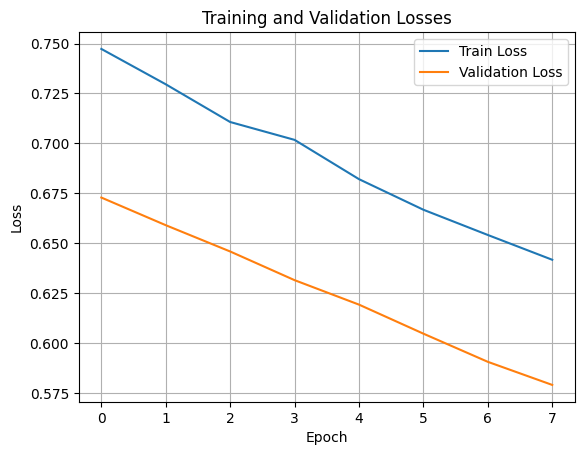

Accuracy: 0.7578
Precision: 0.5490
Recall: 0.9701
F1-score: 0.7012

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.67      0.80      2260
         1.0       0.55      0.97      0.70       936

    accuracy                           0.76      3196
   macro avg       0.77      0.82      0.75      3196
weighted avg       0.86      0.76      0.77      3196



In [ ]:

# train and evaluate the model on enron1
enron1_charswap_train_loss_history,enron1_charswap_valid_loss_history = train_evaluate_save_loop(enron1_charswap_model, train_loader_enron1_charswap, val_loader_enron1_charswap, enron1_charswap_optimizer, enron1_charswap_criterion,dataset_name='enron1_charswap')

# plot the losses
plot_losses(enron1_charswap_train_loss_history, enron1_charswap_valid_loss_history)

# test the model
test_model(enron1_charswap_model, test_loader_enron1_charswap)



Epoch: 1
Train Loss: 1.381 | Train Acc: 34.35%
Val. Loss: 2.261 |  Val. Acc: 15.90%

Epoch: 2
Train Loss: 1.135 | Train Acc: 41.17%
Val. Loss: 2.157 |  Val. Acc: 28.05%

Epoch: 3
Train Loss: 0.973 | Train Acc: 53.37%
Val. Loss: 2.102 |  Val. Acc: 39.73%

Epoch: 4
Train Loss: 0.868 | Train Acc: 61.54%
Val. Loss: 2.058 |  Val. Acc: 48.18%

Epoch: 5
Train Loss: 0.789 | Train Acc: 68.75%
Val. Loss: 1.930 |  Val. Acc: 52.64%

Epoch: 6
Train Loss: 0.725 | Train Acc: 73.07%
Val. Loss: 1.830 |  Val. Acc: 56.02%

Epoch: 7
Train Loss: 0.661 | Train Acc: 76.75%
Val. Loss: 1.785 |  Val. Acc: 59.76%

Epoch: 8
Train Loss: 0.597 | Train Acc: 81.50%
Val. Loss: 1.701 |  Val. Acc: 62.78%



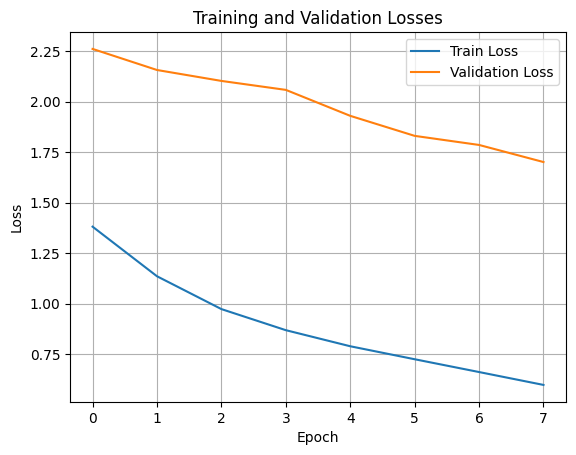

Accuracy: 0.6517
Precision: 0.3103
Recall: 0.1536
F1-score: 0.2055

Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      0.86      0.78       706
         1.0       0.31      0.15      0.21       293

    accuracy                           0.65       999
   macro avg       0.51      0.51      0.49       999
weighted avg       0.59      0.65      0.61       999



In [ ]:

# do the same for enron1_homoglyph
enron1_homoglyph_train_loss_history,enron1_homoglyph_valid_loss_history = train_evaluate_save_loop(enron1_homoglyph_model, train_loader_enron1_homoglyph, val_loader_enron1_homoglyph, enron1_homoglyph_optimizer, enron1_homoglyph_criterion,dataset_name='enron1_homoglyph')

# plot the losses
plot_losses(enron1_homoglyph_train_loss_history, enron1_homoglyph_valid_loss_history)

# test the model
test_model(enron1_homoglyph_model, test_loader_enron1_homoglyph)


Epoch: 1
Train Loss: 1.430 | Train Acc: 35.74%
Val. Loss: 1.288 |  Val. Acc: 43.44%

Epoch: 2
Train Loss: 1.192 | Train Acc: 45.99%
Val. Loss: 1.113 |  Val. Acc: 48.98%

Epoch: 3
Train Loss: 1.064 | Train Acc: 50.93%
Val. Loss: 0.987 |  Val. Acc: 55.02%

Epoch: 4
Train Loss: 0.959 | Train Acc: 57.60%
Val. Loss: 0.898 |  Val. Acc: 60.82%

Epoch: 5
Train Loss: 0.883 | Train Acc: 62.44%
Val. Loss: 0.829 |  Val. Acc: 65.52%

Epoch: 6
Train Loss: 0.815 | Train Acc: 67.72%
Val. Loss: 0.770 |  Val. Acc: 69.27%

Epoch: 7
Train Loss: 0.757 | Train Acc: 72.03%
Val. Loss: 0.719 |  Val. Acc: 72.64%

Epoch: 8
Train Loss: 0.705 | Train Acc: 75.19%
Val. Loss: 0.669 |  Val. Acc: 76.49%



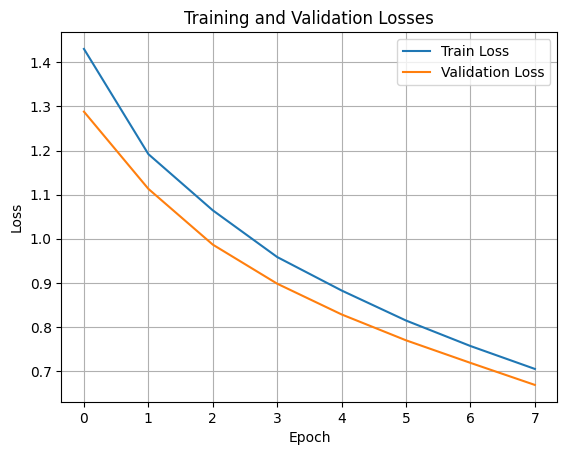

Accuracy: 0.7668
Precision: 0.5743
Recall: 0.7918
F1-score: 0.6657

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.76      0.82       706
         1.0       0.57      0.79      0.67       293

    accuracy                           0.77       999
   macro avg       0.74      0.77      0.74       999
weighted avg       0.80      0.77      0.78       999



In [ ]:
#  do the same for spacing
enron1_spacing_train_loss_history,enron1_spacing_valid_loss_history = train_evaluate_save_loop(enron1_spacing_model, train_loader_enron1_spacing, val_loader_enron1_spacing, enron1_spacing_optimizer, enron1_spacing_criterion,dataset_name='enron1_spacing')

# plot the losses
plot_losses(enron1_spacing_train_loss_history, enron1_spacing_valid_loss_history)

# test the model
test_model(enron1_spacing_model, test_loader_enron1_spacing)
